In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Download Coco

In [2]:
# 1. Tải file annotations (chứa text/caption)
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip

# 2. Tập Validation (1GB - nên dùng để test code trước)
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip val2017.zip

# Tập train (18GB)
!wget http://images.cocodataset.org/zips/train2017.zip
!unzip train2017.zip

Streaming output truncated to the last 5000 lines.
 extracting: train2017/000000259556.jpg  
 extracting: train2017/000000381931.jpg  
 extracting: train2017/000000569592.jpg  
 extracting: train2017/000000229396.jpg  
 extracting: train2017/000000488990.jpg  
 extracting: train2017/000000348684.jpg  
 extracting: train2017/000000234031.jpg  
 extracting: train2017/000000563584.jpg  
 extracting: train2017/000000276069.jpg  
 extracting: train2017/000000401194.jpg  
 extracting: train2017/000000502089.jpg  
 extracting: train2017/000000192183.jpg  
 extracting: train2017/000000425127.jpg  
 extracting: train2017/000000126766.jpg  
 extracting: train2017/000000324161.jpg  
 extracting: train2017/000000452746.jpg  
 extracting: train2017/000000423782.jpg  
 extracting: train2017/000000546343.jpg  
 extracting: train2017/000000249290.jpg  
 extracting: train2017/000000025529.jpg  
 extracting: train2017/000000316928.jpg  
 extracting: train2017/000000337866.jpg  
 extracting: train2017/00

## Tải dữ liệu, Thư viện và Cấu hình



In [3]:
!pip install pycocotools nltk
import re
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Cố định seed để tái lập kết quả
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Từ điển
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: '<START>', 2:'<END>', 3: '<UNK>'}
        self.stoi = {'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_text(text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', '', text)
        return text.split()

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_text(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_text(text)
        return [self.stoi.get(token, self.stoi['<UNK>']) for token in tokenized_text]

## Dataset + Dataloader

In [4]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CustomCocoDataset(Dataset):
    def __init__(self, coco_dataset, vocab):
        self.coco_dataset = coco_dataset
        self.vocab = vocab

    def __len__(self):
        return len(self.coco_dataset)

    def __getitem__(self, index):
        image, captions_dict = self.coco_dataset[index]
        captions = [cap['caption'] for cap in captions_dict]
        selected_caption = random.choice(captions)

        numericalized_caption = [self.vocab.stoi["<START>"]]
        numericalized_caption += self.vocab.numericalize(selected_caption)
        numericalized_caption.append(self.vocab.stoi["<END>"])

        return image, torch.tensor(numericalized_caption)

class CapsCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)
        return imgs, targets

# 1. Khởi tạo Dataset gốc
train_coco_dataset = dset.CocoDetection(root="./train2017", annFile="./annotations/captions_train2017.json", transform=transform)
val_coco_dataset = dset.CocoDetection(root="./val2017", annFile="./annotations/captions_val2017.json", transform=transform)

# 2. Xây dựng Vocab từ Train Dataset
print("Đang xây dựng bộ từ vựng...")
vocab = Vocabulary(freq_threshold=5)

# LẤY TRỰC TIẾP TEXT TỪ BỘ NHỚ
all_captions = [ann['caption'] for ann in train_coco_dataset.coco.anns.values()]

vocab.build_vocab(all_captions)
print(f"Kích thước bộ từ vựng: {len(vocab)} từ")

# 3. Custom Dataset & DataLoader
pad_idx = vocab.stoi["<PAD>"]
train_dataset = CustomCocoDataset(train_coco_dataset, vocab)
val_dataset = CustomCocoDataset(val_coco_dataset, vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,
    collate_fn=CapsCollate(pad_idx)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,
    collate_fn=CapsCollate(pad_idx)
)

loading annotations into memory...
Done (t=1.66s)
creating index...
index created!
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Đang xây dựng bộ từ vựng...
Kích thước bộ từ vựng: 10307 từ


## Xây mạng học sâu

## Encoder (CNN) + Decoder (Transformer)

In [5]:
import torch
import torch.nn as nn

class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.feature_projection = nn.Sequential(nn.Linear(256, embed_size), nn.ReLU(), nn.Dropout(0.5))
        self.position_embedding = nn.Embedding(196, embed_size)

    def forward(self, images):
        features = self.conv_layers(images) # (B, 256, 14, 14)
        B, C, H, W = features.shape
        features = features.view(B, C, H * W).permute(0, 2, 1) # (B, 196, 256)
        features = self.feature_projection(features) # (B, 196, embed_size)
        positions = torch.arange(H * W, device=images.device).unsqueeze(0)
        return features + self.position_embedding(positions)

class DecoderTransformer(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads=8, num_layers=4, dropout=0.1, max_length=50):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)

        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_size, nhead=num_heads,
                                                   dim_feedforward=embed_size * 4, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, seq_len, device):
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
        return mask.bool().to(device)

    def forward(self, features, captions):
        # LƯU Ý: Không cắt captions[:, :-1] ở đây nữa, giữ nguyên để inference dùng được
        B, seq_len = captions.shape
        positions = torch.arange(seq_len, device=captions.device).unsqueeze(0).expand(B, seq_len)

        tgt = self.word_embedding(captions) + self.position_embedding(positions)
        tgt = self.dropout(tgt)
        tgt_mask = self.generate_mask(seq_len, captions.device)

        outputs = self.transformer_decoder(tgt=tgt, memory=features, tgt_mask=tgt_mask)
        return self.fc_out(outputs)

class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()
        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderTransformer(embed_size, vocab_size, num_heads, num_layers, dropout)

    def forward(self, images, captions):
        features = self.encoder(images)
        return self.decoder(features, captions)

# KHỞI TẠO VÀ TÍNH TOÁN THAM SỐ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embed_size = 256
vocab_size = len(vocab)

# Khởi tạo mô hình
model = ImageCaptioningModel(embed_size, vocab_size).to(device)

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    encoder_params = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
    decoder_params = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)

    print(f" ĐÁNH GIÁ SỐ LƯỢNG THAM SỐ TỐI ƯU TOÀN MẠNG")
    print(f"1. Khối CNN Encoder: {encoder_params:,} tham số")
    print(f"2. Khối Transformer Decoder: {decoder_params:,} tham số")
    print(f"-> TỔNG SỐ THAM SỐ HUẤN LUYỆN: {total_params:,} tham số")

# Gọi hàm in ra màn hình
count_parameters(model)

 ĐÁNH GIÁ SỐ LƯỢNG THAM SỐ TỐI ƯU TOÀN MẠNG
1. Khối CNN Encoder: 505,344 tham số
2. Khối Transformer Decoder: 9,514,051 tham số
-> TỔNG SỐ THAM SỐ HUẤN LUYỆN: 10,019,395 tham số


## Test code

In [6]:
from torch.utils.data import Subset
print("Đang tạo tập dữ liệu test thử (1000 ảnh)")
subset_indices = random.sample(range(len(train_dataset)), 1000)
test_dataset_mini = Subset(train_dataset, subset_indices)

# 1. Cho vào DataLoader
test_loader_mini = DataLoader(
    test_dataset_mini,
    batch_size=32,
    shuffle=True,
    collate_fn=CapsCollate(pad_idx)
)
print(f"Đã tạo xong! Số batch test thử: {len(test_loader_mini)}")
# 2. KHAI BÁO LOSS VÀ OPTIMIZER
vocab_size = len(vocab)
learning_rate = 3e-4

# Hàm Loss bỏ qua các token padding
criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_idx)
# Tối ưu hóa bằng Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 3. CHẠY VÒNG LẶP TEST (SANITY CHECK)
model.train()
test_total_loss = 0

# Thanh tiến trình
test_loop = tqdm(test_loader_mini, total=len(test_loader_mini), leave=True)
test_loop.set_description("Test Code (1 Epoch)")

for imgs, captions in test_loop:
    imgs = imgs.to(device)
    captions = captions.to(device)

    # Đưa vào mạng dự đoán
    outputs = model(imgs, captions[:, :-1])

    # Tính Loss
    loss = criterion(
        outputs.reshape(-1, vocab_size),
        captions[:, 1:].reshape(-1)
    )

    # Cập nhật trọng số
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient Clipping
    optimizer.step()

    test_total_loss += loss.item()
    test_loop.set_postfix(loss=loss.item())

test_avg_loss = test_total_loss / len(test_loader_mini)
print(f"\n Hoàn thành Test Code! Average Loss: {test_avg_loss:.4f}")
print("Sẵn sàng huấn luyện!")

Đang tạo tập dữ liệu test thử (1000 ảnh)
Đã tạo xong! Số batch test thử: 32


Test Code (1 Epoch): 100%|██████████| 32/32 [00:21<00:00,  1.52it/s, loss=5.77]


 Hoàn thành Test Code! Average Loss: 6.9216
Sẵn sàng huấn luyện!


## Training Loop

Tìm thấy checkpoint tại /content/drive/MyDrive/Custom_ImageCaptioning_Checkpoints/last_checkpoint.pth. Đang tải...
Tải thành công! Tiếp tục từ Epoch 16


Epoch [16/20]: 100%|██████████| 3697/3697 [21:37<00:00,  2.85it/s, loss=2.2]


Kết thúc Epoch 16 | Average Loss: 2.4677
Đã cập nhật Best Model (Loss giảm xuống: 2.4677)


Epoch [17/20]: 100%|██████████| 3697/3697 [21:34<00:00,  2.86it/s, loss=2.06]


Kết thúc Epoch 17 | Average Loss: 2.4529
Đã cập nhật Best Model (Loss giảm xuống: 2.4529)


...

Kết thúc Epoch 18 | Average Loss: 2.4452
Đã cập nhật Best Model (Loss giảm xuống: 2.4452)


Epoch [19/20]: 100%|██████████| 3697/3697 [21:50<00:00,  2.82it/s, loss=2.57]


Kết thúc Epoch 19 | Average Loss: 2.4306
Đã cập nhật Best Model (Loss giảm xuống: 2.4306)


Epoch [20/20]: 100%|██████████| 3697/3697 [21:40<00:00,  2.84it/s, loss=2.4]


Kết thúc Epoch 20 | Average Loss: 2.4215
Đã cập nhật Best Model (Loss giảm xuống: 2.4215)


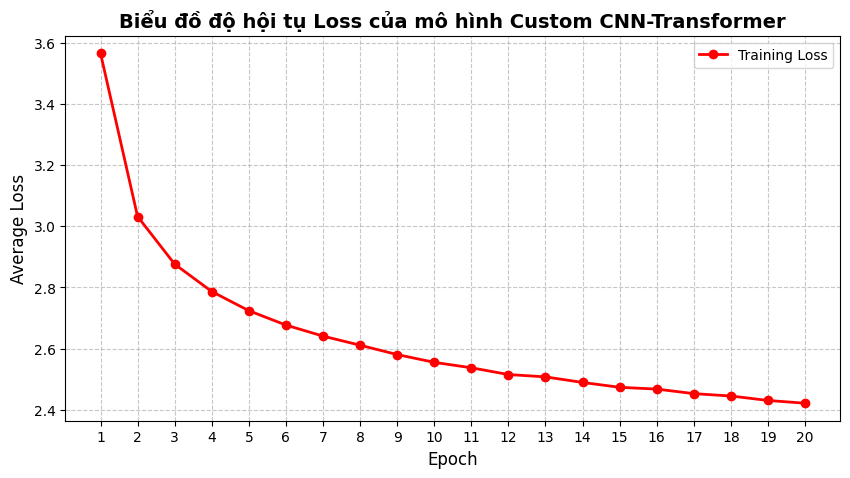

In [7]:
# 1. CẤU HÌNH HUẤN LUYỆN
learning_rate = 3e-4
num_epochs = 20
vocab_size = len(vocab)
pad_idx = vocab.stoi["<PAD>"]

# Hàm Loss (Bỏ qua token PAD để không tính sai loss)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Cấu hình lưu Checkpoint
CHECKPOINT_DIR = "/content/drive/MyDrive/Custom_ImageCaptioning_Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_CKPT = os.path.join(CHECKPOINT_DIR, "best_model.pth")
LAST_CKPT = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")

start_epoch = 0
best_loss = float("inf")
train_losses = []

# 2. KIỂM TRA CHECKPOINT
if os.path.exists(LAST_CKPT):
    print(f"Tìm thấy checkpoint tại {LAST_CKPT}. Đang tải...")
    checkpoint = torch.load(LAST_CKPT, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint.get("best_loss", float("inf"))
    train_losses = checkpoint.get("train_losses", [])

    print(f"Tải thành công! Tiếp tục từ Epoch {start_epoch + 1}")
else:
    print("Bắt đầu huấn luyện")

# 3. TRAINING LOOP
for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0

    # Thanh tiến trình TQDM
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")

    for imgs, captions in loop:
        imgs = imgs.to(device)
        captions = captions.to(device)

        # FORWARD PASS
        # Bỏ token <END> khi đưa vào mô hình dự đoán
        outputs = model(imgs, captions[:, :-1])

        # TÍNH LOSS
        # So sánh với target đã bỏ token <START>
        loss = criterion(
            outputs.reshape(-1, vocab_size),
            captions[:, 1:].reshape(-1)
        )

        # BACKWARD PASS
        optimizer.zero_grad()
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # Tính toán và lưu Log (Log metric)
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Kết thúc Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

    # LƯU CHECKPOINT
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_loss": best_loss,
        "train_losses": train_losses
    }, LAST_CKPT)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss
        }, BEST_CKPT)
        print(f"Đã cập nhật Best Model (Loss giảm xuống: {best_loss:.4f})")

# 4. VẼ BIỂU ĐỒ ĐÁNH GIÁ (LEARNING CURVE)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', color='red', linewidth=2, label='Training Loss')
plt.title("Biểu đồ độ hội tụ Loss của mô hình Custom CNN-Transformer", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Average Loss", fontsize=12)
plt.xticks(range(1, len(train_losses) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Đánh giá

In [8]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=5d044b8e568151da90cd93fc512da023b78a1cb1877176fdad3a9c5e0a54d3a7
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


Đã tải thành công model từ Epoch 20 (Loss: 2.4215)

Đang chạy dự đoán và tính BLEU & ROUGE trên 20 batches tập Validation...


100%|██████████| 20/20 [00:38<00:00,  1.92s/it]



 Kết quả đánh giá:
 - BLEU-1: 0.3152
 - BLEU-4: 0.0596
 - ROUGE-L: 0.3166


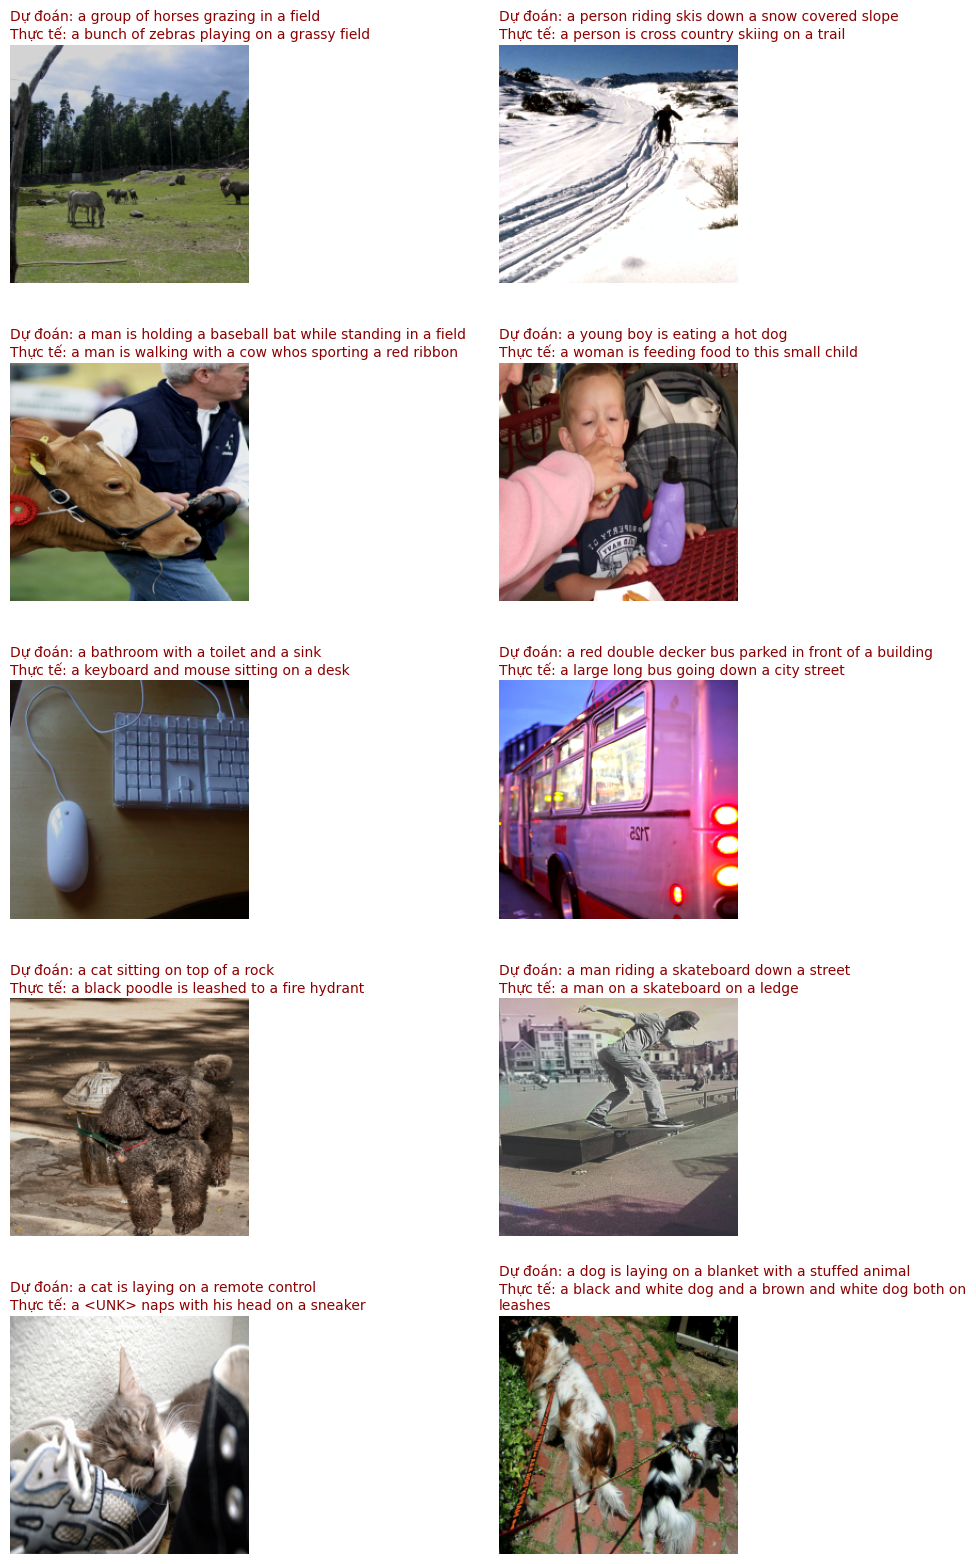

In [11]:
import time
from rouge_score import rouge_scorer

# 1. TẢI LẠI MÔ HÌNH TỐT NHẤT TỪ CHECKPOINT
if os.path.exists(BEST_CKPT):
    checkpoint = torch.load(BEST_CKPT, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"Đã tải thành công model từ Epoch {checkpoint['epoch']+1} (Loss: {checkpoint['best_loss']:.4f})")
else:
    print("Không tìm thấy file best_model.pth. Đang dùng model ở trạng thái hiện tại.")
    model.eval()

# 2. HÀM DỰ ĐOÁN TỪNG TỪ (AUTOREGRESSIVE)
def generate_caption(model, image, vocab, device, max_length=50):
    image = image.unsqueeze(0).to(device)
    result = [vocab.stoi["<START>"]]

    with torch.no_grad():
        features = model.encoder(image)
        for _ in range(max_length):
            caption_tensor = torch.tensor([result], dtype=torch.long).to(device)
            outputs = model.decoder(features, caption_tensor)
            next_word_idx = outputs[:, -1, :].argmax(-1).item()
            result.append(next_word_idx)
            if next_word_idx == vocab.stoi["<END>"]:
                break

    sentence = []
    for idx in result:
        word = vocab.itos.get(idx, "<UNK>")
        if word not in ("<START>", "<END>", "<PAD>"):
            sentence.append(word)
    return " ".join(sentence)

# 3. HÀM TÍNH ĐIỂM BLEU & ROUGE SCORE
def evaluate_metrics(model, dataloader, vocab, device, max_batches=20):
    references_bleu = []
    hypotheses_bleu = []

    # Khởi tạo mảng lưu dữ liệu cho ROUGE
    references_rouge = []
    hypotheses_rouge = []

    print(f"\nĐang chạy dự đoán và tính BLEU & ROUGE trên {max_batches} batches tập Validation...")
    with torch.no_grad():
        for batch_idx, (imgs, captions) in enumerate(tqdm(dataloader, total=max_batches)):
            if batch_idx >= max_batches:
                break
            imgs = imgs.to(device)

            for i in range(imgs.size(0)):
                pred_sentence = generate_caption(model, imgs[i], vocab, device)
                pred_tokens = pred_sentence.split()

                gt_tokens = []
                for idx in captions[i]:
                    word = vocab.itos.get(idx.item(), "<UNK>")
                    if word not in ("<START>", "<END>", "<PAD>"):
                        gt_tokens.append(word)

                # Dữ liệu cho BLEU (Yêu cầu dạng list of lists)
                references_bleu.append([gt_tokens])
                hypotheses_bleu.append(pred_tokens)

                # Dữ liệu cho ROUGE (Yêu cầu dạng chuỗi text hoàn chỉnh)
                references_rouge.append(" ".join(gt_tokens))
                hypotheses_rouge.append(" ".join(pred_tokens))

    # Tính điểm BLEU
    bleu1 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(1.0, 0, 0, 0))
    bleu4 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(0.25, 0.25, 0.25, 0.25))

    # Tính điểm ROUGE-L
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_l_scores = []
    for ref, hyp in zip(references_rouge, hypotheses_rouge):
        score = scorer.score(ref, hyp)['rougeL'].fmeasure
        rouge_l_scores.append(score)
    rouge_l_avg = sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0.0

    return bleu1, bleu4, rouge_l_avg

# CHẠY TÍNH TOÁN
bleu1, bleu4, rouge_l = evaluate_metrics(model, val_loader, vocab, device, max_batches=20)
print(f"\n Kết quả đánh giá:")
print(f" - BLEU-1: {bleu1:.4f}")
print(f" - BLEU-4: {bleu4:.4f}")
print(f" - ROUGE-L: {rouge_l:.4f}")

# 4. TRỰC QUAN HÓA KẾT QUẢ TRÊN 10 BỨC ẢNH
import time
import random
import matplotlib.pyplot as plt
import numpy as np

# Cập nhật thời gian thực để ảnh lấy ra luôn mới
random.seed(time.time())

# Tạo lưới 5 hàng x 2 cột. Kích thước (12, 16)
fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.flatten()

for i in range(10):
    # Lấy ngẫu nhiên 1 index
    random_idx = random.randint(0, len(val_dataset)-1)

    # CHUẨN BỊ ẢNH ĐỂ ĐƯA VÀO MÔ HÌNH DỰ ĐOÁN
    sample_img_tensor, sample_captions = val_dataset[random_idx]

    # Mô hình tự dự đoán
    pred_text = generate_caption(model, sample_img_tensor, vocab, device)

    # Lấy câu đáp án thực tế
    gt_text = [vocab.itos.get(idx.item(), "<UNK>") for idx in sample_captions]
    gt_text = " ".join([w for w in gt_text if w not in ("<START>", "<END>", "<PAD>")])

    # CHUẨN BỊ ẢNH ĐỂ VẼ RA MÀN HÌNH (Khử Normalize)
    img_display = sample_img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean # Đảo ngược Normalize
    img_display = np.clip(img_display, 0, 1) # Ép lại vào khoảng [0, 1] để vẽ

    # Vẽ ảnh vào lưới
    axes[i].imshow(img_display)
    axes[i].axis('off')

    # Đặt tiêu đề
    title = f"Dự đoán: {pred_text}\nThực tế: {gt_text}"
    axes[i].set_title(title, wrap=True, fontsize=10, color="darkred", loc='left')

plt.tight_layout(pad=2.0)
plt.show()

##### Đánh giá trên toàn tập val


Đang đánh giá mô hình trên toàn tập Validation...


Calculating: 100%|██████████| 157/157 [04:44<00:00,  1.81s/it]



ĐÁNH GIÁ ĐỊNH LƯỢNG
* Điểm BLEU-1 Trung bình : 0.3199
* Điểm BLEU-4 Trung bình : 0.0643
* Điểm ROUGE-L Trung bình: 0.3172


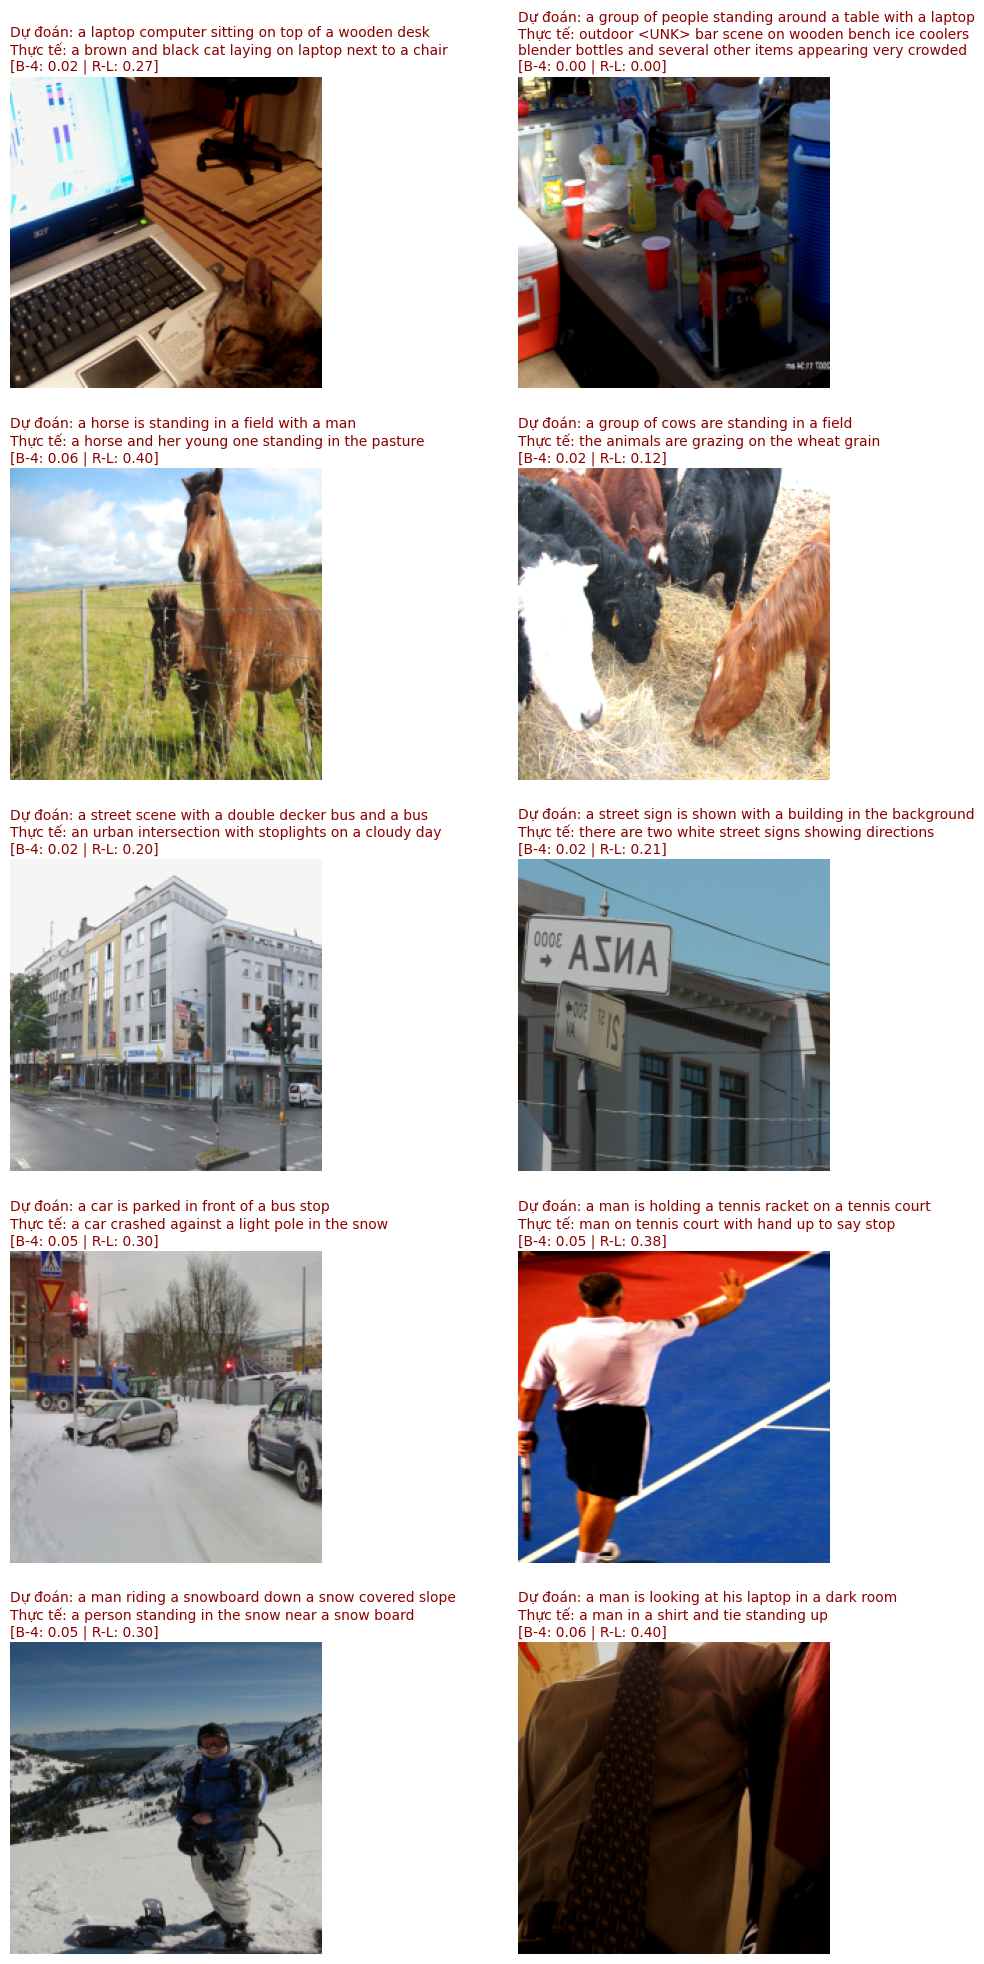

In [16]:
import time
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# 1. HÀM DỰ ĐOÁN TỪNG TỪ CHO TRANSFORMER
def generate_caption(model, image, vocab, device, max_length=50):
    image = image.unsqueeze(0).to(device)
    result = [vocab.stoi["<START>"]]
    with torch.no_grad():
        features = model.encoder(image)
        for _ in range(max_length):
            caption_tensor = torch.tensor([result], dtype=torch.long).to(device)
            outputs = model.decoder(features, caption_tensor)
            next_word_idx = outputs[:, -1, :].argmax(-1).item()
            result.append(next_word_idx)
            if next_word_idx == vocab.stoi["<END>"]:
                break
    sentence = []
    for idx in result:
        word = vocab.itos.get(idx, "<UNK>")
        if word not in ("<START>", "<END>", "<PAD>"):
            sentence.append(word)
    return " ".join(sentence)

# 2. HÀM ĐÁNH GIÁ TOÀN TẬP DATASET (CORPUS LEVEL)
def evaluate_metric(model, dataloader, vocab, device):
    model.eval()
    references_bleu = []
    hypotheses_bleu = []
    references_rouge = []
    hypotheses_rouge = []

    print(f"\nĐang đánh giá mô hình trên toàn tập Validation...")
    with torch.no_grad():
        for imgs, captions in tqdm(dataloader, desc="Calculating"):
            imgs = imgs.to(device)
            for i in range(imgs.size(0)):
                # Lấy dự đoán
                pred_sentence = generate_caption(model, imgs[i], vocab, device)
                pred_tokens = pred_sentence.split()

                # Lấy đáp án
                gt_tokens = []
                for idx in captions[i]:
                    word = vocab.itos.get(idx.item(), "<UNK>")
                    if word not in ("<START>", "<END>", "<PAD>"):
                        gt_tokens.append(word)

                # Thu thập dữ liệu
                references_bleu.append([gt_tokens])
                hypotheses_bleu.append(pred_tokens)
                references_rouge.append(" ".join(gt_tokens))
                hypotheses_rouge.append(" ".join(pred_tokens))

    # Tính toán Corpus BLEU chuẩn mực
    bleu1 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(1.0, 0, 0, 0))
    bleu4 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(0.25, 0.25, 0.25, 0.25))

    # Tính toán ROUGE-L trung bình
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_l_scores = [scorer.score(ref, hyp)['rougeL'].fmeasure for ref, hyp in zip(references_rouge, hypotheses_rouge)]
    rouge_l_avg = sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0.0

    print(f"\nĐÁNH GIÁ ĐỊNH LƯỢNG")
    print(f"* Điểm BLEU-1 Trung bình : {bleu1:.4f}")
    print(f"* Điểm BLEU-4 Trung bình : {bleu4:.4f}")
    print(f"* Điểm ROUGE-L Trung bình: {rouge_l_avg:.4f}")

    return bleu1, bleu4, rouge_l_avg

# 3. HÀM HIỂN THỊ ẢNH
def show_predict(model, dataset, vocab, device, num_samples=10):
    model.eval()
    random.seed(time.time())

    # Lấy mẫu ngẫu nhiên
    random_indices = random.sample(range(len(dataset)), num_samples)

    # Tự động tính số hàng cần thiết (mỗi hàng 2 cột)
    num_rows = (num_samples + 1) // 2
    fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(random_indices):
            sample_img_tensor, sample_captions = dataset[idx]

            # CHUẨN BỊ ẢNH VẼ (Đảo ngược chuẩn hóa để không bị mờ)
            img_display = sample_img_tensor.permute(1, 2, 0).cpu().numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_display = std * img_display + mean
            img_display = np.clip(img_display, 0, 1)

            # Dự đoán & Đáp án
            pred_text = generate_caption(model, sample_img_tensor, vocab, device)
            gt_text = [vocab.itos.get(w.item(), "<UNK>") for w in sample_captions]
            gt_text = " ".join([w for w in gt_text if w not in ("<START>", "<END>", "<PAD>")])

            # Tính điểm lẻ tẻ cho riêng bức ảnh đó
            chencherry = SmoothingFunction()
            b4_score = sentence_bleu([gt_text.split()], pred_text.split(), weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)

            scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
            r_score = scorer.score(gt_text, pred_text)['rougeL'].fmeasure

            # Vẽ ảnh và in kết quả
            axes[i].imshow(img_display)
            axes[i].axis('off')

            title = f"Dự đoán: {pred_text}\nThực tế: {gt_text}\n[B-4: {b4_score:.2f} | R-L: {r_score:.2f}]"
            axes[i].set_title(title, wrap=True, fontsize=10, color="darkred", loc='left')

    # Xóa các ô trống nếu số ảnh test là số lẻ
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=2.0)
    plt.show()

# 4. THỰC THI
# A. Đánh giá toàn tập Validation
_ = evaluate_metric(model, val_loader, vocab, device)

# B. Vẽ lưới 10 bức ảnh ngẫu nhiên
show_predict(model, val_dataset, vocab, device, num_samples=10)

In [ ]:
from torch.utils.data import Subset, DataLoader

# ==========================================
# DỰ ĐOÁN & ĐÁNH GIÁ 100 ẢNH ĐẦU TIÊN TẬP TEST
# ==========================================

print("Đang trích xuất 100 ảnh đầu tiên từ tập Test...")

# 1. Cắt lấy 100 index đầu tiên (từ 0 đến 99)
first_100_indices = list(range(100))
test_dataset_100 = Subset(test_dataset, first_100_indices)

# 2. Tạo DataLoader riêng cho 100 ảnh này
# Mẹo: Mượn luôn collate_fn từ val_loader để đảm bảo code không bị lỗi kích thước Padding
test_loader_100 = DataLoader(
    test_dataset_100,
    batch_size=32,
    shuffle=False, # Đặt False để máy tính giữ nguyên thứ tự 100 ảnh đầu tiên
    collate_fn=val_loader.collate_fn
)

# 3. Đưa vào hàm đánh giá để tính điểm BLEU & ROUGE
print("\nBắt đầu chạy dự đoán...")
test_bleu1, test_bleu4, test_rouge_l = evaluate_metric(model, test_loader_100, vocab, device)

# 4. (Tùy chọn) In luôn kết quả của 5 ảnh đầu tiên ra màn hình cho trực quan
print("\n KẾT QUẢ DỰ ĐOÁN THỰC TẾ 5 ẢNH ĐẦU TIÊN ")
for i in range(100):
    img_tensor, captions = test_dataset_100[i]

    # Dự đoán
    pred_text = generate_caption(model, img_tensor, vocab, device)

    # Đáp án thực tế
    gt_text = [vocab.itos.get(idx.item(), "<UNK>") for idx in captions]
    gt_text = " ".join([w for w in gt_text if w not in ("<START>", "<END>", "<PAD>")])

    print(f"Ảnh thứ {i+1}:")
    print(f"Dự đoán: {pred_text}")
    print(f"Thực tế: {gt_text}")
    print("-" * 50)

#### Dự đoán trên tập test

In [17]:
# Tập test
!wget http://images.cocodataset.org/zips/test2017.zip
!unzip test2017.zip

Streaming output truncated to the last 5000 lines.
 extracting: test2017/000000251604.jpg  
 extracting: test2017/000000145034.jpg  
 extracting: test2017/000000234833.jpg  
 extracting: test2017/000000025927.jpg  
 extracting: test2017/000000393116.jpg  
 extracting: test2017/000000536478.jpg  
 extracting: test2017/000000365460.jpg  
 extracting: test2017/000000089887.jpg  
 extracting: test2017/000000274928.jpg  
 extracting: test2017/000000310028.jpg  
 extracting: test2017/000000229793.jpg  
 extracting: test2017/000000394339.jpg  
 extracting: test2017/000000564538.jpg  
 extracting: test2017/000000440585.jpg  
 extracting: test2017/000000541512.jpg  
 extracting: test2017/000000395525.jpg  
 extracting: test2017/000000235435.jpg  
 extracting: test2017/000000069964.jpg  
 extracting: test2017/000000131962.jpg  
 extracting: test2017/000000281392.jpg  
 extracting: test2017/000000534893.jpg  
 extracting: test2017/000000128676.jpg  
 extracting: test2017/000000187639.jpg  
 extra

 DỰ ĐOÁN 100 ẢNH TỪ TẬP TEST

Bắt đầu dự đoán 100 ảnh

[1/100] Ảnh 000000333711.jpg -> AI đoán: a row of motorcycles parked next to each other
[2/100] Ảnh 000000498355.jpg -> AI đoán: a herd of sheep standing on top of a lush green field
[3/100] Ảnh 000000397621.jpg -> AI đoán: a man standing on a beach holding a surfboard
[4/100] Ảnh 000000309305.jpg -> AI đoán: a double decker bus is parked in a parking lot
[5/100] Ảnh 000000422034.jpg -> AI đoán: a giraffe standing in a field of grass
[6/100] Ảnh 000000525454.jpg -> AI đoán: a bathroom with a toilet and a sink
[7/100] Ảnh 000000048302.jpg -> AI đoán: a man riding skis down a snow covered slope
[8/100] Ảnh 000000567092.jpg -> AI đoán: a plate of food with a sandwich and a side of fries
[9/100] Ảnh 000000572964.jpg -> AI đoán: a living room with a couch and a tv
[10/100] Ảnh 000000549791.jpg -> AI đoán: a zebra is standing in a field of grass
[11/100] Ảnh 000000160505.jpg -> AI đoán: a woman is sitting at a table with a plate of food


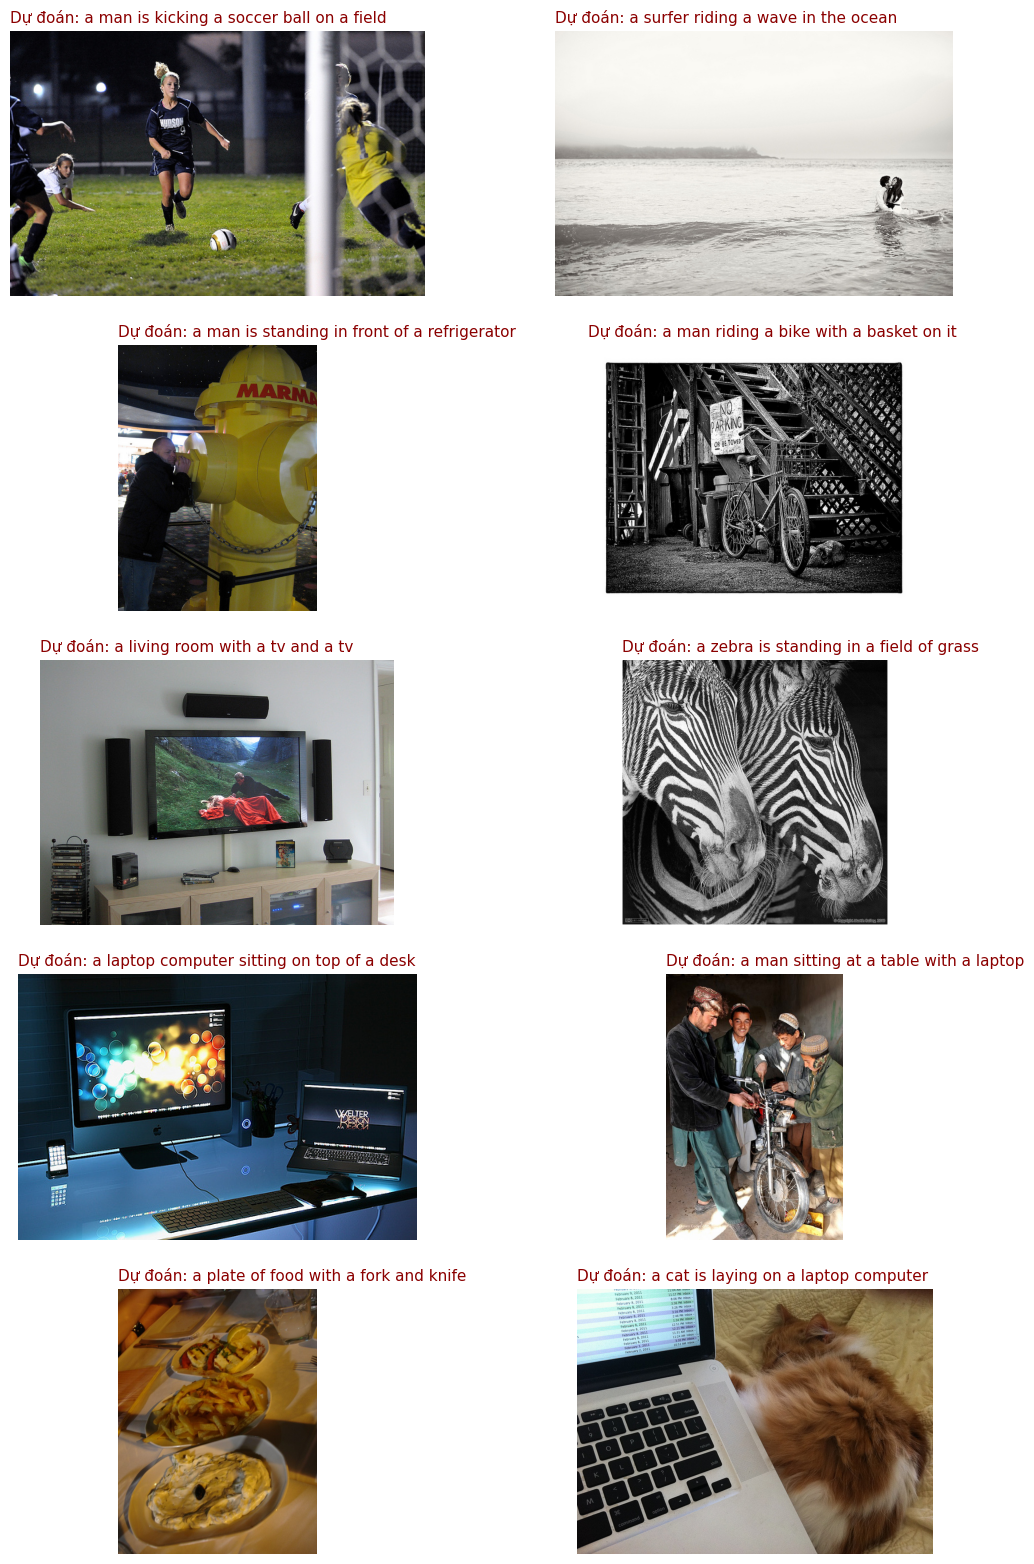

In [20]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

print(" DỰ ĐOÁN 100 ẢNH TỪ TẬP TEST")
# 1. Khởi tạo bộ biến đổi ảnh dành cho Test
test_transform = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop((224, 224)), # Lấy phần trung tâm ảnh thay vì cắt ngẫu nhiên
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Quét thư mục và lấy 100 ảnh đầu tiên
test_dir = "./test2017"
try:
    all_test_images = os.listdir(test_dir)
    test_100_images = all_test_images[:100]
except FileNotFoundError:
    print(f"Không tìm thấy thư mục {test_dir}. Bạn đã giải nén file test2017.zip chưa?")
    test_100_images = []

results = []

if test_100_images:
    print("\nBắt đầu dự đoán 100 ảnh\n")
    model.eval()

    # 3. Vòng lặp dự đoán 100 ảnh
    for i, img_name in enumerate(test_100_images):
        img_path = os.path.join(test_dir, img_name)
        img_hd = Image.open(img_path).convert('RGB')

        # Tiền xử lý ảnh thành tensor
        img_tensor = test_transform(img_hd).to(device)

        # Cho AI đọc và sinh câu
        pred_text = generate_caption(model, img_tensor, vocab, device)

        # Lưu lại để lát vẽ
        results.append((img_hd, pred_text))

        # In text ra màn hình (In đủ 100 câu)
        print(f"[{i+1}/100] Ảnh {img_name} -> AI đoán: {pred_text}")

    # 4. Trực quan hóa (Vẽ 10 ảnh ngẫu nhiên trong số 100 ảnh)
    print("\n" + "="*50)
    print("TRỰC QUAN HÓA 10 ẢNH ĐẠI DIỆN")

    fig, axes = plt.subplots(5, 2, figsize=(12, 16))
    axes = axes.flatten()

    # Bốc ngẫu nhiên 10 ảnh từ danh sách kết quả
    sample_results = random.sample(results, 10)

    for i, (img_hd, pred_text) in enumerate(sample_results):
        axes[i].imshow(img_hd)
        axes[i].axis('off')

        title = f"Dự đoán: {pred_text}"
        axes[i].set_title(title, wrap=True, fontsize=11, color="darkred", loc='left')

    plt.tight_layout(pad=2.0)
    plt.show()